In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv("Ads_CTR_Optimisation.csv")
N, d = df.shape

In [ ]:
def run_epsilon_greedy(epsilon, df): 
    np.random.seed(42)

    numbers_of_selections = [0] * d  # her bir reklamın kaç kere gösterildiği
    sums_of_rewards = [0] * d # her reklamın toplam tıklama sayısı
    total_reward = 0  # toplam tıklama sayısı

    for n in range(N):
        if np.random.rand() < epsilon:
            ad = np.random.randint(0, d)
        else:
            means = []
            for i in range(d):
                if numbers_of_selections[i] > 0:
                    mean = sums_of_rewards[i] / numbers_of_selections[i]
                else:
                    mean = 0
                means.append(mean)
            ad = np.argmax(means)
        reward = df.values[n, ad]
        numbers_of_selections[ad] += 1
        sums_of_rewards[ad] += reward
        total_reward += reward

    return total_reward, numbers_of_selections


reward_01, counts_01 = run_epsilon_greedy(0.10, df)

print(f"Epsilon = 0.10 için Toplam Tıklama Sayısı: {reward_01}")
print("Reklamların Gösterilme Sayıları:", counts_01)

Epsilon = 0.10 için Toplam Tıklama Sayısı: 2543
Reklamların Gösterilme Sayıları: [297, 107, 91, 100, 8870, 108, 97, 107, 111, 112]


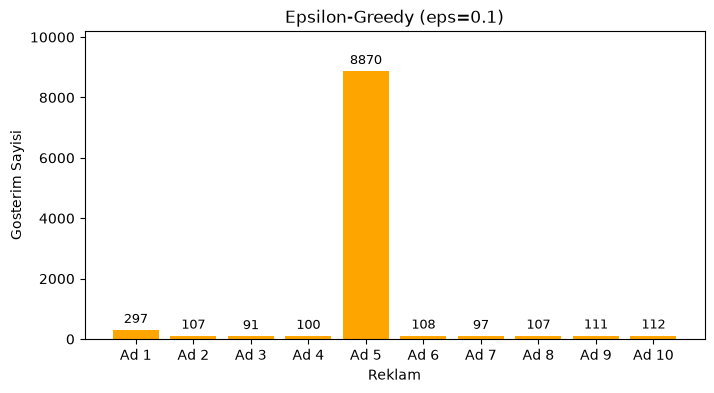

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
bars = plt.bar(range(d), counts_01, color='orange', width=0.8)

plt.title(f'Epsilon-Greedy (eps=0.1)')
plt.xlabel('Reklam')
plt.ylabel('Gosterim Sayisi')
plt.bar_label(bars, padding=3, fontsize=9)
plt.ylim(0, max(counts_01) * 1.15)
plt.xticks(range(d), [f'Ad {i+1}' for i in range(d)])

plt.show()